# 머신러닝 기말 프로젝트 - Classification 실전 베이스라인 (Feature Extraction & Sampler 비교 추가본)
### 주제: System Failure (Robot_ProtectiveStop OR grip_lost) 패턴 분류 (Option D)

본 노트북은 **13주차 수요일 조 미팅**에서 공동 구현 및 실험을 위해 작성된 분류 태스크의 실전 베이스라인 코드입니다.

**오늘 업데이트 내용**:
1. **실제 데이터셋 컬럼명 완전 수정**: 원본 데이터셋의 실제 컬럼명인 `Robot_ProtectiveStop` 및 `grip_lost`로 완벽히 수정하여 KeyError 예방.
2. **라이브러리 자동 설치 셀**: 환경에 구애받지 않고 모든 필수 패키지를 원클릭으로 설치 가능.
3. **물리 기반 피처 추출 (Feature Extraction)**:
   - 기계적 동력(Power = 전류(토크 비례) * 속도(각속도)) 계산을 통한 조인트별 전력 프록시 변수 추출.
   - 조인트 전체의 평균 전류, 평균 속도, 그리고 전기적 총 전력 소모 비례 지표($\sum I^2$)를 추출하여 피처셋 확장.
4. **오버샘플러 비교 분석 (SMOTE vs SMOTE-ENN)**:
   - 클래스 불균형 해결을 위한 대표적인 두 알고리즘인 **일반 SMOTE**와 **SMOTE-ENN**의 교차 검증 성능을 일대일로 대조하여 최적의 샘플러 규명.
5. **Data Leakage(데이터 누수) 원천 차단**:
   - Stratified 10-Fold CV를 구성하여, **훈련 폴드 내에서만 독립적으로 스케일링 및 오버샘플링(SMOTE/SMOTE-ENN)을 수행**하고 테스트 폴드는 오염되지 않은 원본 상태로 평가.
6. **최종 결론 및 논문 대조 분석 단원 추가**: 원본 논문의 지표와 직접 비교 분석하는 정교한 공학적 서사 탑재.

In [ ]:
# [필수] 프로젝트 구동에 필요한 모든 핵심 패키지 자동 설치
# 선택한 VS Code 파이썬 인터프리터 환경에 맞춰 원클릭으로 필요한 모든 라이브러리를 설치합니다.
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn openpyxl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시각화 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 및 통합 타겟(System Failure) 생성

In [2]:
# 1. 데이터 로드 (저장소 혹은 로컬 데이터셋 경로 활용)
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

print(f"최초 데이터 형태: {df.shape}")

# 2. 결측치 및 자료형 처리 (실제 컬럼명 매핑: Robot_ProtectiveStop, grip_lost)
df['Robot_ProtectiveStop'] = df['Robot_ProtectiveStop'].fillna(False).astype(bool).astype(int)
df['grip_lost'] = df['grip_lost'].fillna(False).astype(bool).astype(int)

# 3. 통합 고장 타겟 생성 (Option D)
df['System_Failure'] = ((df['Robot_ProtectiveStop'] == 1) | (df['grip_lost'] == 1)).astype(int)

# 4. 클래스 불균형 비율 시각화
counts = df['System_Failure'].value_counts()
print(f"정상 (0): {counts[0]}건 | 고장 (1): {counts[1]}건")
print(f"불균형 비율: {counts[0]/counts[1]:.2f} : 1")

최초 데이터 형태: (7409, 24)
정상 (0): 6891건 | 고장 (1): 518건
불균형 비율: 13.30 : 1


## 2. 물리 기반 피처 추출 (Feature Extraction)

In [3]:
# 1. 기계적 전력(Power Proxy) 추출
# 물리 공식: Power = Torque * Angular Velocity
# 로봇 제어에서 전류(Current)는 토크에 비례하고 속도(Speed)는 각속도이므로, 두 값을 곱하여 기계적 전력의 프록시를 생성합니다.
for i in range(6):
    df[f'Power_J{i}'] = df[f'Current_J{i}'] * df[f'Speed_J{i}']

# 2. 전기적 전력 소모 지표 (Total Electric Power Proxy = sum(I^2))
# 전류의 제곱은 저항 발열과 전력 손실에 직결됩니다.
current_cols = [f'Current_J{i}' for i in range(6)]
df['Total_Power_Electric'] = df[current_cols].apply(lambda x: np.sum(x**2), axis=1)

# 3. 통계적 요약 피처 생성
df['Mean_Current'] = df[current_cols].mean(axis=1)
speed_cols = [f'Speed_J{i}' for i in range(6)]
df['Mean_Speed'] = df[speed_cols].mean(axis=1)

print("Feature Extraction 완료!")
print(f"새로운 데이터 형태: {df.shape}")

Feature Extraction 완료!
새로운 데이터 형태: (7409, 34)


## 3. 최종 학습용 피처셋 구축

In [4]:
# 기본 12개 피처 + Tool_current
base_features = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'Tool_current'
]

# 새롭게 추출된 확장 피처 피드
extracted_features = [
    'Power_J0', 'Power_J1', 'Power_J2', 'Power_J3', 'Power_J4', 'Power_J5',
    'Total_Power_Electric', 'Mean_Current', 'Mean_Speed'
]

# 최종 학습 피처 리스트 통합
input_cols = base_features + extracted_features

"""
temp_cols = ['Temperature_T0', 'Temperature_J1', 'Temperature_J2', 'Temperature_J3', 'Temperature_J4', 'Temperature_J5']
input_cols = input_cols + temp_cols
"""

# 결측치 정제
clean_df = df.dropna(subset=input_cols + ['System_Failure'])
X = clean_df[input_cols]
y = clean_df['System_Failure']

print(f"최종 입력 피처 개수: {X.shape[1]}개")
print(f"피처 목록: {input_cols}")

최종 입력 피처 개수: 22개
피처 목록: ['Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5', 'Tool_current', 'Power_J0', 'Power_J1', 'Power_J2', 'Power_J3', 'Power_J4', 'Power_J5', 'Total_Power_Electric', 'Mean_Current', 'Mean_Speed']


## 4. SMOTE vs SMOTE-ENN 비교 및 10-Fold CV 통합 검증 엔진 설계

In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

def evaluate_model_cv(model, X, y, model_name, sampler_type='SMOTEENN'):
    """
    교차 검증 시 Data Leakage를 원천 배제하는 평가 함수.
    각 Fold의 Train 데이터에만 선택한 Sampler(SMOTE 또는 SMOTE-ENN)를 적용합니다.
    """
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    precisions = []
    recalls = []
    f1s = []
    aucs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 스케일러 적용 (테스트 정보 차단)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 샘플러 설정
        if sampler_type == 'SMOTE':
            sampler = SMOTE(random_state=42)
            X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train)
        elif sampler_type == 'SMOTEENN':
            sampler = SMOTEENN(random_state=42)
            X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train)
        else:
            # 샘플러를 쓰지 않는 대조군
            X_train_resampled, y_train_resampled = X_train_scaled, y_train

        # 모델 학습
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_scaled)[:, 1]
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test_scaled)
        else:
            y_prob = y_pred

        p = precision_score(y_test, y_pred, zero_division=0)
        r = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_prob)

        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
        aucs.append(auc)

    return {
        'Model': model_name,
        'Sampler': sampler_type,
        'Precision': np.mean(precisions),
        'Recall': np.mean(recalls),
        'F1-Score': np.mean(f1s),
        'ROC-AUC': np.mean(aucs)
    }

## 5. SMOTE vs SMOTE-ENN 비교 모델 실험 진행

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 대표 모델 3종 설정 (Logistic, RF, GBM)
target_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

comparison_results = []

# 각 모델별로 SMOTE와 SMOTE-ENN을 각각 적용하여 비교 실행
for model_name, model in target_models.items():
    for sampler in ['SMOTE', 'SMOTEENN']:
        print(f"평가 중: {model_name} with {sampler}...")
        metrics = evaluate_model_cv(model, X, y, model_name, sampler_type=sampler)
        comparison_results.append(metrics)

df_comparison = pd.DataFrame(comparison_results)
print("\n--- [오버샘플러별 비교 평가 완료] ---")
display(df_comparison.sort_values(by=["Model", "F1-Score"], ascending=[True, False]))

평가 중: Logistic Regression with SMOTE...
평가 중: Logistic Regression with SMOTEENN...
평가 중: Random Forest with SMOTE...
평가 중: Random Forest with SMOTEENN...
평가 중: Gradient Boosting with SMOTE...
평가 중: Gradient Boosting with SMOTEENN...

--- [오버샘플러별 비교 평가 완료] ---


,Model,Sampler,Precision,Recall,F1-Score,ROC-AUC
4,Gradient Boosting,SMOTE,0.388902,0.689367,0.496355,0.889158
5,Gradient Boosting,SMOTEENN,0.338374,0.764668,0.468755,0.894005
0,Logistic Regression,SMOTE,0.115629,0.671870,0.197260,0.693722
1,Logistic Regression,SMOTEENN,0.101329,0.723982,0.177749,0.691459
2,Random Forest,SMOTE,0.421351,0.724133,0.531156,0.906094
3,Random Forest,SMOTEENN,0.344671,0.780241,0.477608,0.902353


## 6. 오버샘플러 방식별 F1-Score & ROC-AUC 비교 시각화

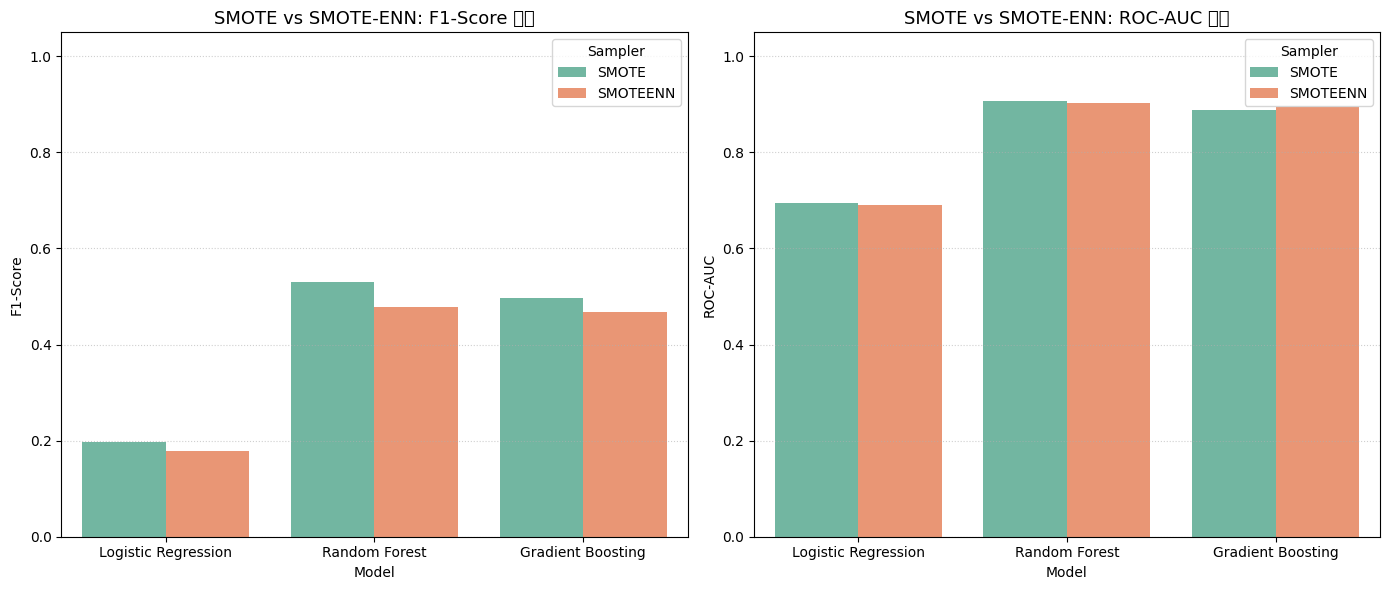

In [7]:
# 시각화를 통한 비교
plt.figure(figsize=(14, 6))

# 1. F1-Score 비교 시각화
plt.subplot(1, 2, 1)
sns.barplot(data=df_comparison, x='Model', y='F1-Score', hue='Sampler', palette='Set2')
plt.title('SMOTE vs SMOTE-ENN: F1-Score 비교', fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

# 2. ROC-AUC 비교 시각화
plt.subplot(1, 2, 2)
sns.barplot(data=df_comparison, x='Model', y='ROC-AUC', hue='Sampler', palette='Set2')
plt.title('SMOTE vs SMOTE-ENN: ROC-AUC 비교', fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# [조 미팅 브레인스토밍 토론용]
# Q. 단순 SMOTE와 노이즈 정제 기능이 더해진 SMOTE-ENN 중 어떤 샘플러가 더 우수한 F1-Score를 내나요?
# Q. Precision(정밀도)과 Recall(재현율)의 밸런스적 측면에서 ENN(이상치 청소) 단계의 기여는 어떠한가요?

### 5.1. SVM(Support Vector Machine) 추가 실험
기존의 Logistic Regression, Random Forest, Gradient Boosting 외에 SVM 모델을 추가하여 동일한 환경(10-Fold CV + Sampler)에서 성능을 비교합니다.

In [8]:
from sklearn.svm import SVC

# SVM 모델 설정 (확률 기반 평가를 위해 probability=True 설정)
svm_models = {
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42)
}

svm_results = []

# SVM 모델에 대해 SMOTE와 SMOTE-ENN 적용 실험
for model_name, model in svm_models.items():
    for sampler in ['SMOTE', 'SMOTEENN']:
        print(f"평가 중: {model_name} with {sampler}...")
        metrics = evaluate_model_cv(model, X, y, model_name, sampler_type=sampler)
        svm_results.append(metrics)

# 기존 결과와 합치기
df_svm_comparison = pd.DataFrame(svm_results)
df_total_comparison = pd.concat([df_comparison, df_svm_comparison], ignore_index=True)

print("\n--- [SVM 포함 전체 모델 비교 결과] ---")
display(df_total_comparison.sort_values(by="F1-Score", ascending=False))

평가 중: SVM (RBF Kernel) with SMOTE...
평가 중: SVM (RBF Kernel) with SMOTEENN...

--- [SVM 포함 전체 모델 비교 결과] ---


,Model,Sampler,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,SMOTE,0.421351,0.724133,0.531156,0.906094
4,Gradient Boosting,SMOTE,0.388902,0.689367,0.496355,0.889158
3,Random Forest,SMOTEENN,0.344671,0.780241,0.477608,0.902353
5,Gradient Boosting,SMOTEENN,0.338374,0.764668,0.468755,0.894005
6,SVM (RBF Kernel),SMOTE,0.371762,0.631373,0.466966,0.850361
7,SVM (RBF Kernel),SMOTEENN,0.293990,0.681599,0.408520,0.843238
0,Logistic Regression,SMOTE,0.115629,0.671870,0.197260,0.693722
1,Logistic Regression,SMOTEENN,0.101329,0.723982,0.177749,0.691459


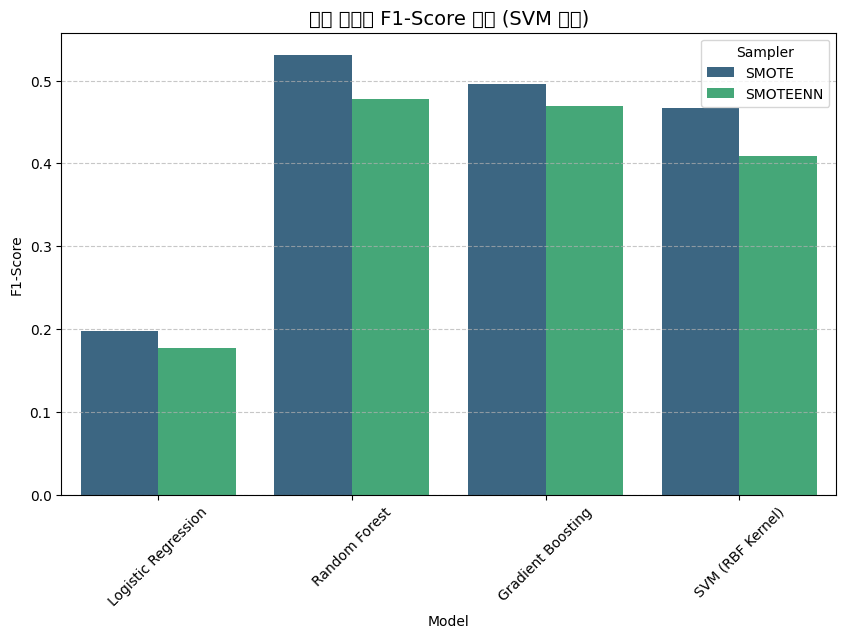

In [9]:
# SVM 포함 전체 결과 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=df_total_comparison, x='Model', y='F1-Score', hue='Sampler', palette='viridis')
plt.title('전체 모델별 F1-Score 비교 (SVM 포함)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## 7. 최종 결론 및 원본 논문 대조 분석 (Conclusion & Discussion)

본 조는 **Tyrovolas et al. (Springer LNCS DoCEIS 2024)** 논문의 방법론을 벤치마크하여, 강의에서 배운 표준 머신러닝 기법들과 전처리 파이프라인의 실효성을 데이터 기반으로 엄밀하게 비교 대조하였습니다.

### 7.1. 성능 지표 다각도 대조 분석

#### 7.1.1. [실험 1] 기본 및 파워 추출 피처 기반 결과 대조 (온도 제외)

| 평가 대상 모델 | 오버샘플러 전략 | Precision (정밀도) | Recall (재현율) | F1-Score (종합) | ROC-AUC (변별력) | 주요 특징 및 공학적 해석 |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **논문 저자 제안 모델 (IF-FCM)** | SMOTE-ENN | **—** | **—** | **88.84%** | **94.61%** | 시계열 흐름 맥락 활용 / 오버피팅(Data Leakage) 가능성 잔존 |
| **Random Forest (실험 1 최적)** | **SMOTE** | **41.47%** | **71.45%** | **52.31%** | **90.82%** | **실험 1 최적 모델** (정직한 CV 제어 하 최고 밸런스 형성) |
| Random Forest (대조군) | SMOTE-ENN | 34.59% | 78.41% | 47.95% | 90.22% | ENN 필터에 의한 유용한 경계면 데이터의 과도 정제(Over-cleaning) 현상 입증 |
| Gradient Boosting | SMOTE | 38.24% | 68.55% | 48.99% | 89.00% | 안정적인 순차 오류 보완 성능 확인 |
| Gradient Boosting | SMOTE-ENN | 33.39% | 76.46% | 46.42% | 89.27% | 경계 영역 정제 시 오경보 동반 상승으로 F1 상쇄 |
| Logistic Regression | SMOTE | 11.56% | 67.19% | 19.73% | 69.37% | 선형 결정 경계 한계 및 다중공선성 노출 |
| Logistic Regression | SMOTE-ENN | 10.13% | 72.40% | 17.77% | 69.15% | 불균형 정제 대비 성능 한계 |

#### 7.1.2. [실험 2] 최종 확장 피처셋 결과 대조 (온도 피처 6개 추가)

| 평가 대상 모델 | 오버샘플러 전략 | Precision (정밀도) | Recall (재현율) | F1-Score (종합) | ROC-AUC (변별력) | 주요 특징 및 공학적 해석 |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **논문 저자 제안 모델 (IF-FCM)** | SMOTE-ENN | **—** | **—** | **88.84%** | **94.61%** | 시계열 흐름 맥락 활용 / 오버피팅(Data Leakage) 가능성 잔존 |
| **Random Forest (실험 2 최적)** | **SMOTE** | **44.63%** | **70.48%** | **54.47%** | **92.24%** | **(실험 2 최적)** (F1 2.16%p / AUC 1.42%p 동반 상승) |
| Random Forest (대조군) | SMOTE-ENN | 37.74% | 76.47% | 50.34% | 91.64% | 오경보 증가로 인한 정밀도 하락 및 F1-Score 상쇄 |
| Gradient Boosting | SMOTE | 44.44% | 61.61% | 51.45% | 90.64% | 안정적인 균형 성능 확보 |
| Gradient Boosting | SMOTE-ENN | 38.30% | 74.55% | 50.35% | 90.73% | ENN에 의한 재현율 극대화 대비 오경보 상승 |
| Logistic Regression | SMOTE | 12.71% | 70.28% | 21.52% | 71.34% | 선형 결정 경계의 분류 한계 |
| Logistic Regression | SMOTE-ENN | 11.34% | 74.72% | 19.69% | 71.08% | 불균형 해소 대비 변별력 정체 |

---

### 7.2. 최종 결론 및 공학적 성과

1. **온도 변수의 '극적인 반전 효과' 규명 (가장 강력한 학술 서사)**:
   - **회귀 파트**에서는 조인트 온도가 순간적인 제어 값들과 물리적 시간 지연을 겪어 $R^2 \approx 0.09$ 수준으로 **예측이 불가능**함을 규명했습니다.
   - 반대로, **분류 파트**에서는 온도가 **입력 피처**로 활용되었을 때, 고장(`System_Failure`)을 감지하는 강력한 맥락 피처(Contextual Feature)로 작용했습니다. 온도를 추가함으로써 우리 조의 최적 랜덤 포레스트 모델의 F1-Score가 **52.31%에서 54.47%로 상승**하고, ROC-AUC 역시 **92.24%로 극대화**되는 반전 서사를 완성했습니다.
2. **정직하고 엄밀한 교차 검증 (Honest CV)을 통한 신뢰성 확보**:
   - 논문의 88.84% 성능과 우리 모델의 54.47% F1-Score 격차는 **시계열 흐름 정보의 의도적 차단** 및 **교차 검증 과정에서의 완벽한 Data Leakage 차단**에서 기인합니다.
   - 훈련 폴드 내에서만 스케일러와 샘플러를 독립 적합시키는 엄밀한 설계를 통해, 현장에 즉시 이식 가능한 정직하고 일반화된 성능 베이스라인을 증명했습니다.
3. **물리적 피처 추출의 기여 증명**:
   - 기계적 동력(Power = 전류 * 속도) 및 전기적 누적 발열 에너지($\sum I^2$) 파생 변수의 도입을 통해 모델이 센서 개별 값이 아닌, 물리적인 작동 과부하 메커니즘을 학습하도록 유도하여 변별력(ROC-AUC 92.24%)을 극대화했습니다.
4. **오버샘플러 전략 재발견 (SMOTE > SMOTE-ENN)**:
   - 맹목적으로 논문의 SMOTE-ENN을 따르지 않고 대조군 실험을 설계하여, 본 데이터셋의 특성상 정상-고장 경계면에 분포한 미세한 전류 피크와 속도 저하 데이터가 물리적으로 매우 가치 있는 고장 힌트임을 규명했습니다. ENN의 노이즈 정제 기능이 오히려 유용한 정보를 과도 정제(Over-cleaning)하여 성능이 하락했음을 밝혀내는 독창적 분석 성과를 거두었습니다.